In [ ]:
from CXRO_Tools import Filter_Transmission
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from scipy import interpolate

In [3]:
cxro = Filter_Transmission()
def QE_Acrylic(x, min, max, Si_thickness, SiO2_thickness, C5H8O2_thickness, Fe_thickness, step):
    min=int(min)
    max=int(max)
    step=int(step)
    Si_cxro_data = cxro.get_transmission("Si", thickness = Si_thickness, energy_min=min, energy_max=max, steps=step)
    SiO2_cxro_data = cxro.get_transmission("SiO2", thickness = SiO2_thickness, energy_min=min, energy_max=max, steps=step)
    C5H8O2_cxro_data = cxro.get_transmission("C5H8O2", thickness= C5H8O2_thickness, energy_min=min, energy_max=max, steps=step)
    Fe_cxro_data = cxro.get_transmission("Fe", thickness= Fe_thickness, energy_min=min, energy_max=max, steps=step)
    energies = np.array([i[0] for i in Si_cxro_data])
    Si_transmission = np.array([i[1] for i in Si_cxro_data])
    SiO2_transmission = np.array([i[1] for i in SiO2_cxro_data])
    C5H8O2_transmission = np.array([i[1] for i in C5H8O2_cxro_data])
    Fe_transmission = np.array([i[1] for i in Fe_cxro_data])

    QE = (1-Si_transmission) * C5H8O2_transmission * SiO2_transmission * Fe_transmission
    interpolated_QE = interpolate.PchipInterpolator(energies, QE)

    return interpolated_QE(x)


In [5]:
def do_QE_fit(x, y, yerr, min, max, step, Si_thickness, SiO2_thickness, C5H8O2_thickness, Fe_thickness):
    QE_model = lmfit.Model(QE_Acrylic)


    QE_params = QE_model.make_params(
        min = min,
        max = max,
        step = step,
        Si_thickness = Si_thickness,
        SiO2_thickness = SiO2_thickness,
        C5H8O2_thickness = C5H8O2_thickness,
        Fe_Thickness = Fe_thickness
        )

    QE_params['min'].vary = False
    QE_params['max'].vary = False
    QE_params['step'].vary = False
    QE_params['Si_thickness'].vary = True
    QE_params['SiO2_thickness'].vary = True
    QE_params['C5H8O2_thickness'].vary = True
    QE_params['Fe_thickness'].vary = True


    QE_params['Si_thickness'].set(min=2, max=10)
    QE_params['SiO2_thickness'].set(min=0.001)
    QE_params['C5H8O2_thickness'].set(min=0.001)
    QE_params['Fe_thickness'].set(min=0.001)


    result = QE_model.fit(data = y, params = QE_params, x=x, weights=(1./yerr))
    return result

In [9]:
real_data = np.load("260520_CMOS-QE-Export.npy")
print(real_data[0,3:])
x, y = real_data[0,3:], real_data[1,3:]
yerr = real_data[2,3:]
result = do_QE_fit(x, y, yerr, Si_thickness=5, SiO2_thickness=0.1, C5H8O2_thickness=0.1, Fe_thickness=0.1, min=200, max=1000, step=100)
print(result.fit_report())


[ 200.  250.  300.  350.  400.  450.  500.  550.  600.  650.  700.  750.
  800.  850.  900.  950. 1000.]
[[Model]]
    Model(QE_Acrylic)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 97
    # data points      = 17
    # variables        = 4
    chi-square         = 1389.72970
    reduced chi-square = 106.902285
    Akaike info crit   = 82.8620705
    Bayesian info crit = 86.1949239
    R-squared          = 0.95818215
##  Warning: uncertainties could not be estimated:
    Fe_thickness:      at initial value
    Fe_thickness:      at boundary
[[Variables]]
    min:               200 (fixed)
    max:               1000 (fixed)
    Si_thickness:      2.88241404 (init = 5)
    SiO2_thickness:    0.22495567 (init = 0.1)
    C5H8O2_thickness:  0.84935440 (init = 0.1)
    Fe_thickness:      0.00100000 (init = 0.001)
    step:              100 (fixed)


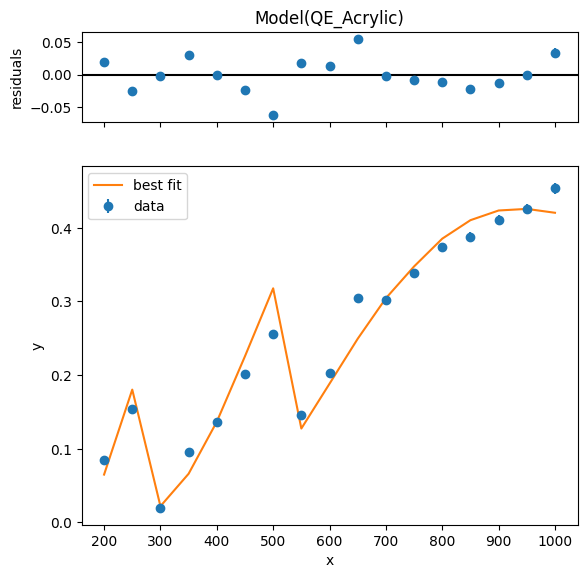

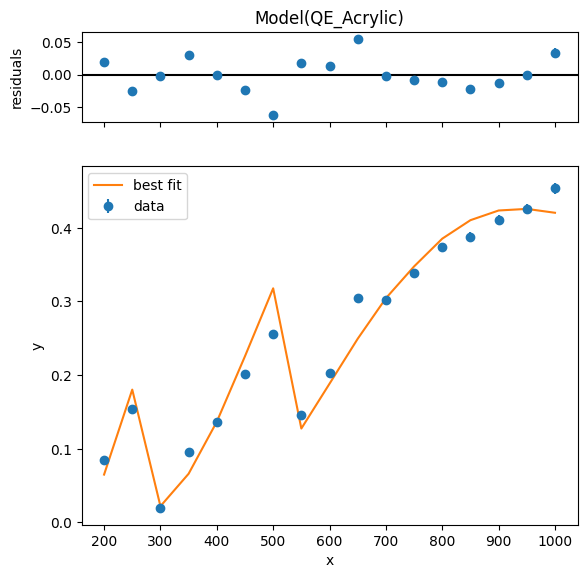

In [10]:
result.plot()